<a href="https://colab.research.google.com/github/ywchanna2001/Protein_Conformational_Ensembles_Prediction/blob/dev/Protein_Conformational_Ensemble_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MSA-Generation module

In [1]:
#@title Input protein sequence(s)
from google.colab import files
import os
import re
import hashlib
import random

from sys import version_info
python_version = f"{version_info.major}.{version_info.minor}"

def add_hash(x,y):
  return x+"_"+hashlib.sha1(y.encode()).hexdigest()[:5]

query_sequence = 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSDYNIQKESTLHLVLRLRGG' #@param {type:"string"}
#@markdown  - Use `:` to specify inter-protein chainbreaks for **modeling complexes** (supports homo- and hetro-oligomers). For example **PI...SK:PI...SK** for a homodimer
jobname = 'Test1' #@param {type:"string"}
# number of models to use
num_relax = 5 #@param [0, 1, 5] {type:"raw"}
#@markdown - specify how many of the top ranked structures to relax using amber
template_mode = "none" #@param ["none", "pdb100","custom"]
#@markdown - `none` = no template information is used. `pdb100` = detect templates in pdb100 (see [notes](#pdb100)). `custom` - upload and search own templates (PDB or mmCIF format, see [notes](#custom_templates))

use_amber = num_relax > 0

# remove whitespaces
query_sequence = "".join(query_sequence.split())

basejobname = "".join(jobname.split())
basejobname = re.sub(r'\W+', '', basejobname)
jobname = add_hash(basejobname, query_sequence)

# check if directory with jobname exists
def check(folder):
  if os.path.exists(folder):
    return False
  else:
    return True
if not check(jobname):
  n = 0
  while not check(f"{jobname}_{n}"): n += 1
  jobname = f"{jobname}_{n}"

# make directory to save results
os.makedirs(jobname, exist_ok=True)

# save queries
queries_path = os.path.join(jobname, f"{jobname}.csv")
with open(queries_path, "w") as text_file:
  text_file.write(f"id,sequence\n{jobname},{query_sequence}")

if template_mode == "pdb100":
  use_templates = True
  custom_template_path = None
elif template_mode == "custom":
  custom_template_path = os.path.join(jobname,f"template")
  os.makedirs(custom_template_path, exist_ok=True)
  uploaded = files.upload()
  use_templates = True
  for fn in uploaded.keys():
    os.rename(fn,os.path.join(custom_template_path,fn))
else:
  custom_template_path = None
  use_templates = False

print("jobname",jobname)
print("sequence",query_sequence)
print("length",len(query_sequence.replace(":","")))

jobname Test1_7686d
sequence MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSDYNIQKESTLHLVLRLRGG
length 76


In [2]:
#@title Install dependencies
%%time
import os
USE_AMBER = use_amber
USE_TEMPLATES = use_templates
PYTHON_VERSION = python_version

if not os.path.isfile("COLABFOLD_READY"):
  print("installing colabfold...")
  os.system("pip install -q --no-warn-conflicts 'colabfold[alphafold-minus-jax] @ git+https://github.com/sokrypton/ColabFold'")
  if os.environ.get('TPU_NAME', False) != False:
    os.system("pip uninstall -y jax jaxlib")
    os.system("pip install --no-warn-conflicts --upgrade dm-haiku==0.0.10 'jax[cuda12_pip]'==0.3.25 -f https://storage.googleapis.com/jax-releases/jax_cuda_releases.html")
  os.system("ln -s /usr/local/lib/python3.*/dist-packages/colabfold colabfold")
  os.system("ln -s /usr/local/lib/python3.*/dist-packages/alphafold alphafold")
  # hack to fix TF crash
  os.system("rm -f /usr/local/lib/python3.*/dist-packages/tensorflow/core/kernels/libtfkernel_sobol_op.so")
  os.system("touch COLABFOLD_READY")

if USE_AMBER or USE_TEMPLATES:
  if not os.path.isfile("CONDA_READY"):
    print("installing conda...")
    os.system("wget -qnc https://github.com/conda-forge/miniforge/releases/latest/download/Miniforge3-Linux-x86_64.sh")
    os.system("bash Miniforge3-Linux-x86_64.sh -bfp /usr/local")
    os.system("mamba config --set auto_update_conda false")
    os.system("touch CONDA_READY")

if USE_TEMPLATES and not os.path.isfile("HH_READY") and USE_AMBER and not os.path.isfile("AMBER_READY"):
  print("installing hhsuite and amber...")
  os.system(f"mamba install -y -c conda-forge -c bioconda kalign2=2.04 hhsuite=3.3.0 openmm=8.2.0 python='{PYTHON_VERSION}' pdbfixer")
  os.system("touch HH_READY")
  os.system("touch AMBER_READY")
else:
  if USE_TEMPLATES and not os.path.isfile("HH_READY"):
    print("installing hhsuite...")
    os.system(f"mamba install -y -c conda-forge -c bioconda kalign2=2.04 hhsuite=3.3.0 python='{PYTHON_VERSION}'")
    os.system("touch HH_READY")
  if USE_AMBER and not os.path.isfile("AMBER_READY"):
    print("installing amber...")
    os.system(f"mamba install -y -c conda-forge openmm=8.2.0 python='{PYTHON_VERSION}' pdbfixer")
    os.system("touch AMBER_READY")

installing colabfold...
installing conda...
installing amber...
CPU times: user 14.6 ms, sys: 3.38 ms, total: 17.9 ms
Wall time: 2min 3s


In [3]:
#@markdown ### MSA options (custom MSA upload, single sequence, pairing mode)
msa_mode = "mmseqs2_uniref_env" #@param ["mmseqs2_uniref_env", "mmseqs2_uniref","single_sequence","custom"]
pair_mode = "unpaired_paired" #@param ["unpaired_paired","paired","unpaired"] {type:"string"}
#@markdown - "unpaired_paired" = pair sequences from same species + unpaired MSA, "unpaired" = seperate MSA for each chain, "paired" - only use paired sequences.

# decide which a3m to use
if "mmseqs2" in msa_mode:
  a3m_file = os.path.join(jobname,f"{jobname}.a3m")

elif msa_mode == "custom":
  a3m_file = os.path.join(jobname,f"{jobname}.custom.a3m")
  if not os.path.isfile(a3m_file):
    custom_msa_dict = files.upload()
    custom_msa = list(custom_msa_dict.keys())[0]
    header = 0
    import fileinput
    for line in fileinput.FileInput(custom_msa,inplace=1):
      if line.startswith(">"):
         header = header + 1
      if not line.rstrip():
        continue
      if line.startswith(">") == False and header == 1:
         query_sequence = line.rstrip()
      print(line, end='')

    os.rename(custom_msa, a3m_file)
    queries_path=a3m_file
    print(f"moving {custom_msa} to {a3m_file}")

else:
  a3m_file = os.path.join(jobname,f"{jobname}.single_sequence.a3m")
  with open(a3m_file, "w") as text_file:
    text_file.write(">1\n%s" % query_sequence)

In [4]:
# --- MODULE 1: ROBUST MSA GENERATION (Fixed) ---
import os
import time
from colabfold.colabfold import run_mmseqs2

search_mode = "mmseqs2_uniref_env"
use_env = "env" in search_mode

print(f"Target Sequence: {query_sequence[:30]}...")
print(f"Job Name: {jobname}")

# ✅ FIX 1: Delete any stale cached .a3m file so the API is actually called
a3m_cache = os.path.join(jobname, f"{jobname}.a3m")
if os.path.isfile(a3m_cache):
    os.remove(a3m_cache)
    print("Removed cached .a3m — forcing fresh API search...")

print("Status: Contacting MMseqs2 server (this can take 1–3 minutes)...")

try:
    # ✅ FIX 2: Capture result correctly — run_mmseqs2 returns a LIST of a3m content strings
    result = run_mmseqs2(
        x=query_sequence,
        prefix=jobname,
        use_env=use_env,
        use_filter=True,           # ✅ FIX 3: Required for proper hit filtering
        use_pairing=False,
    )

    # ✅ FIX 4: Flatten the result into individual lines correctly
    # result is a list of strings; each string can be a full a3m block
    if isinstance(result, list):
        a3m_lines = "\n".join(result).splitlines(keepends=True)
    else:
        a3m_lines = result.splitlines(keepends=True)

    # ✅ FIX 5: Count sequences properly (lines starting with '>')
    num_seqs = sum(1 for line in a3m_lines if line.startswith(">"))

    print(f"Total lines in result: {len(a3m_lines)}")
    print(f"Sequences found (headers): {num_seqs}")

    if num_seqs <= 1:
        print("❌ ERROR: Server returned 0 hits.")
        print("Debugging info:")
        print("".join(a3m_lines[:10]))  # Show first 10 lines for diagnosis
        print("\nPossible causes:")
        print("  - MMseqs2 API server is down or overloaded (try again in 1 min)")
        print("  - Sequence too short/non-standard for database hits")
        print("  - Network issue in Colab (try Runtime > Restart and run all)")
    else:
        # Save valid MSA
        msa_module_dir = "research_msa_output"
        os.makedirs(msa_module_dir, exist_ok=True)
        msa_file_path = os.path.join(msa_module_dir, f"{jobname}.a3m")

        with open(msa_file_path, "w") as f:
            f.writelines(a3m_lines)

        print(f"✅ SUCCESS: {num_seqs} sequences saved to {msa_file_path}")

except Exception as e:
    print(f"❌ SERVER ERROR: {e}")
    import traceback
    traceback.print_exc()

Target Sequence: MQIFVKTLTGKTITLEVEPSDTIENVKAKI...
Job Name: Test1_7686d
Status: Contacting MMseqs2 server (this can take 1–3 minutes)...


COMPLETE: 100%|██████████| 150/150 [elapsed: 00:02 remaining: 00:00]

Total lines in result: 43154
Sequences found (headers): 21577
✅ SUCCESS: 21577 sequences saved to research_msa_output/Test1_7686d.a3m


Query length  : 76
Total sequences: 21577
Plotting 21577 sequences × 76 positions...


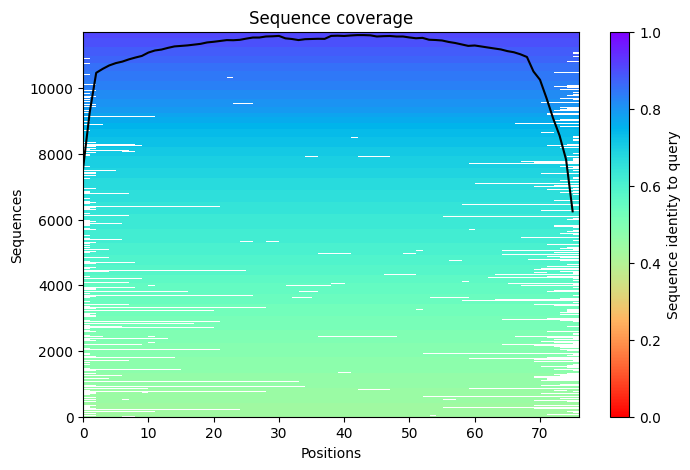

In [6]:
#@title Module 1 Visualization: Authentic ColabFold Plot Style (Fixed)
import numpy as np
import matplotlib.pyplot as plt
from colabfold.plot import plot_msa_v2

def generate_authentic_msa_plot(a3m_lines):
    """
    Replicates the exact behaviour of input_features_callback in the original
    ColabFold run cell, which passes raw input_features directly to plot_msa_v2.
    """

    # ── 1. Parse A3M: keep UPPERCASE only (gaps = '-', insertions = lowercase removed) ──
    sequences = []
    current_seq = []
    for line in a3m_lines:
        line = line.strip()
        if not line:
            continue
        if line.startswith(">"):
            if current_seq:
                sequences.append("".join(current_seq))
            current_seq = []
        else:
            # Keep uppercase residues AND dashes; drop lowercase insertions
            current_seq.append("".join(c if (c.isupper() or c == "-") else "" for c in line))
    if current_seq:
        sequences.append("".join(current_seq))

    if not sequences:
        print("❌ No sequences found in a3m_lines.")
        return

    query_len = len(sequences[0])
    print(f"Query length  : {query_len}")
    print(f"Total sequences: {len(sequences)}")

    # ── 2. Build integer matrix  ──────────────────────────────────────────────
    #   Amino-acid alphabet used by ColabFold's plot_msa_v2:
    #   residue index 20 = gap/unknown  → rendered as NaN (white) by the plotter
    map_str = "ARNDCQEGHILKMFPSTWYV"
    res_map = {c: i for i, c in enumerate(map_str)}
    GAP_IDX = 21   # value for '-' or any unknown character

    msa_list = []
    for seq in sequences:
        row = []
        for c in seq[:query_len]:         # truncate if longer than query
            row.append(res_map.get(c.upper(), GAP_IDX))
        # ✅ KEY FIX: do NOT pad — leave shorter sequences as-is;
        #            pad with GAP_IDX only to keep a rectangular matrix
        if len(row) < query_len:
            row += [GAP_IDX] * (query_len - len(row))
        msa_list.append(row)

    msa_arr = np.array(msa_list, dtype=np.int32)

    # ── 3. Sort by sequence identity to query (creates colour gradient) ───────
    query_row = msa_arr[0]
    # Only count positions where the query itself is not a gap
    query_positions = query_row != GAP_IDX
    if query_positions.sum() > 0:
        identity = np.sum(
            (msa_arr[:, query_positions] == query_row[query_positions]),
            axis=1
        ) / query_positions.sum()
    else:
        identity = np.zeros(len(msa_arr))

    sorted_idx = np.argsort(identity)[::-1]   # highest identity first
    msa_arr    = msa_arr[sorted_idx]
    identity   = identity[sorted_idx]

    # ── 4. Build input_features dict exactly as ColabFold's pipeline does ─────
    #   plot_msa_v2 needs:
    #     "msa"             – int32 array  (N_seq × N_res)
    #     "num_alignments"  – int32 array  (N_res,)  = number of non-gap seqs per column
    #     "sequence"        – optional; the query sequence as a list of residue strings

    # num_alignments = per-column count of sequences that are NOT a gap
    num_alignments = np.sum(msa_arr != GAP_IDX, axis=0).astype(np.int32)

    input_features = {
        "msa":            msa_arr,
        "num_alignments": num_alignments,
    }

    # ── 5. Plot ───────────────────────────────────────────────────────────────
    print(f"Plotting {len(msa_arr)} sequences × {query_len} positions...")
    try:
        plot_msa_v2(input_features)
        plt.show()
    except Exception as e:
        print(f"plot_msa_v2 error: {e}")
        # ── Faithful fallback that still shows gaps and coverage curve ────────
        fig, ax = plt.subplots(figsize=(10, 4))

        # Replace GAP_IDX with NaN so gaps render white
        display = msa_arr.astype(float)
        display[display == GAP_IDX] = np.nan

        ax.imshow(display, aspect="auto", cmap="rainbow_r",
                  vmin=0, vmax=20, interpolation="nearest")
        ax.set_xlabel("Positions")
        ax.set_ylabel("Sequences")
        ax.set_title("Sequence coverage")

        # Draw the coverage curve (black line) — same as original
        ax2 = ax.twinx()
        ax2.plot(num_alignments, color="black", linewidth=1.5)
        ax2.set_ylabel("Coverage")
        ax2.set_ylim(0, len(msa_arr))

        plt.tight_layout()
        plt.show()

# ── Run ───────────────────────────────────────────────────────────────────────
if 'a3m_lines' in locals():
    generate_authentic_msa_plot(a3m_lines)
else:
    print("❌ 'a3m_lines' not found — run the MSA Generation cell first.")

# MODULE 2: DBSCAN CLUSTERING

Loading MSA from disk: research_msa_output/Test1_7686d.a3m
✅ Data Ready. Matrix Shape: (21577, 76) (Sequences, Length)
✅ Found 48 clusters.
✅ Noise sequences (Label -1): 17637


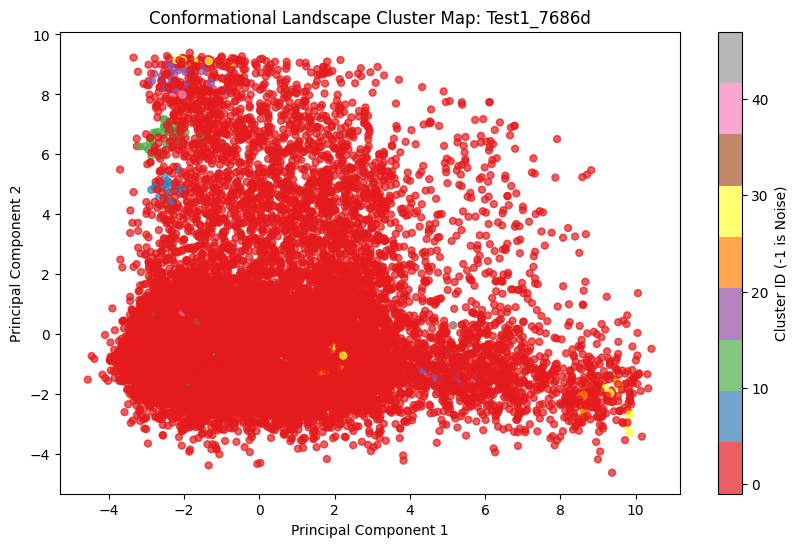

In [7]:
import os
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 1. LOAD DATA DIRECTLY FROM DISK
# This ensures Module 2 works even if you restart the notebook
msa_file_path = f"research_msa_output/{jobname}.a3m"

if os.path.exists(msa_file_path):
    print(f"Loading MSA from disk: {msa_file_path}")

    with open(msa_file_path, "r") as f:
        lines = f.readlines()

    # Parse text sequences into numerical matrix
    processed_seqs = []
    for line in lines:
        line = line.strip()
        if not line or line.startswith(">") or line.startswith("#"):
            continue
        # Remove insertions (lowercase)
        clean_seq = "".join([c for c in line if not c.islower()])
        if clean_seq:
            processed_seqs.append(clean_seq)

    map_str = "ARNDCQEGHILKMFPSTWYV-"
    res_map = {res: i for i, res in enumerate(map_str)}
    msa_indices = [[res_map.get(res.upper(), 21) for res in seq] for seq in processed_seqs]
    msa_arr = np.array(msa_indices)

    print(f"✅ Data Ready. Matrix Shape: {msa_arr.shape} (Sequences, Length)")

    # 2. DIMENSIONALITY REDUCTION (PCA)
    # Standardizing is required for DBSCAN to calculate densities correctly
    scaled_msa = StandardScaler().fit_transform(msa_arr)
    n_pc = min(10, msa_arr.shape[0], msa_arr.shape[1])
    pca = PCA(n_components=n_pc)
    msa_pca = pca.fit_transform(scaled_msa)

    # 3. DBSCAN CLUSTERING
    # Tuning: eps (distance) and min_samples (min density)
    # For research, we'll experiment with these values
    db = DBSCAN(eps=1.2, min_samples=5)
    cluster_labels = db.fit_predict(msa_pca)

    # 4. RESULTS SUMMARY
    unique_labels = set(cluster_labels)
    n_clusters = len(unique_labels) - (1 if -1 in cluster_labels else 0)
    print(f"✅ Found {n_clusters} clusters.")
    print(f"✅ Noise sequences (Label -1): {list(cluster_labels).count(-1)}")

    # 5. VISUALIZATION
    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(msa_pca[:, 0], msa_pca[:, 1], c=cluster_labels, cmap='Set1', s=25, alpha=0.7)
    plt.title(f"Conformational Landscape Cluster Map: {jobname}")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.colorbar(scatter, label="Cluster ID (-1 is Noise)")
    plt.show()

else:
    print(f"❌ Error: File not found at {msa_file_path}. Please run Module 1 again.")

--- Cluster Distribution ---
Noise: 17637 sequences (81.7%)
State 0: 3553 sequences (16.5%)
State 1: 5 sequences (0.0%)
State 2: 6 sequences (0.0%)
State 3: 15 sequences (0.1%)
State 4: 5 sequences (0.0%)
State 5: 3 sequences (0.0%)
State 6: 10 sequences (0.0%)
State 7: 3 sequences (0.0%)
State 8: 18 sequences (0.1%)
State 9: 8 sequences (0.0%)
State 10: 31 sequences (0.1%)
State 11: 4 sequences (0.0%)
State 12: 5 sequences (0.0%)
State 13: 5 sequences (0.0%)
State 14: 5 sequences (0.0%)
State 15: 41 sequences (0.2%)
State 16: 5 sequences (0.0%)
State 17: 17 sequences (0.1%)
State 18: 5 sequences (0.0%)
State 19: 19 sequences (0.1%)
State 20: 5 sequences (0.0%)
State 21: 10 sequences (0.0%)
State 22: 10 sequences (0.0%)
State 23: 9 sequences (0.0%)
State 24: 6 sequences (0.0%)
State 25: 6 sequences (0.0%)
State 26: 18 sequences (0.1%)
State 27: 13 sequences (0.1%)
State 28: 5 sequences (0.0%)
State 29: 5 sequences (0.0%)
State 30: 5 sequences (0.0%)
State 31: 5 sequences (0.0%)
State 3

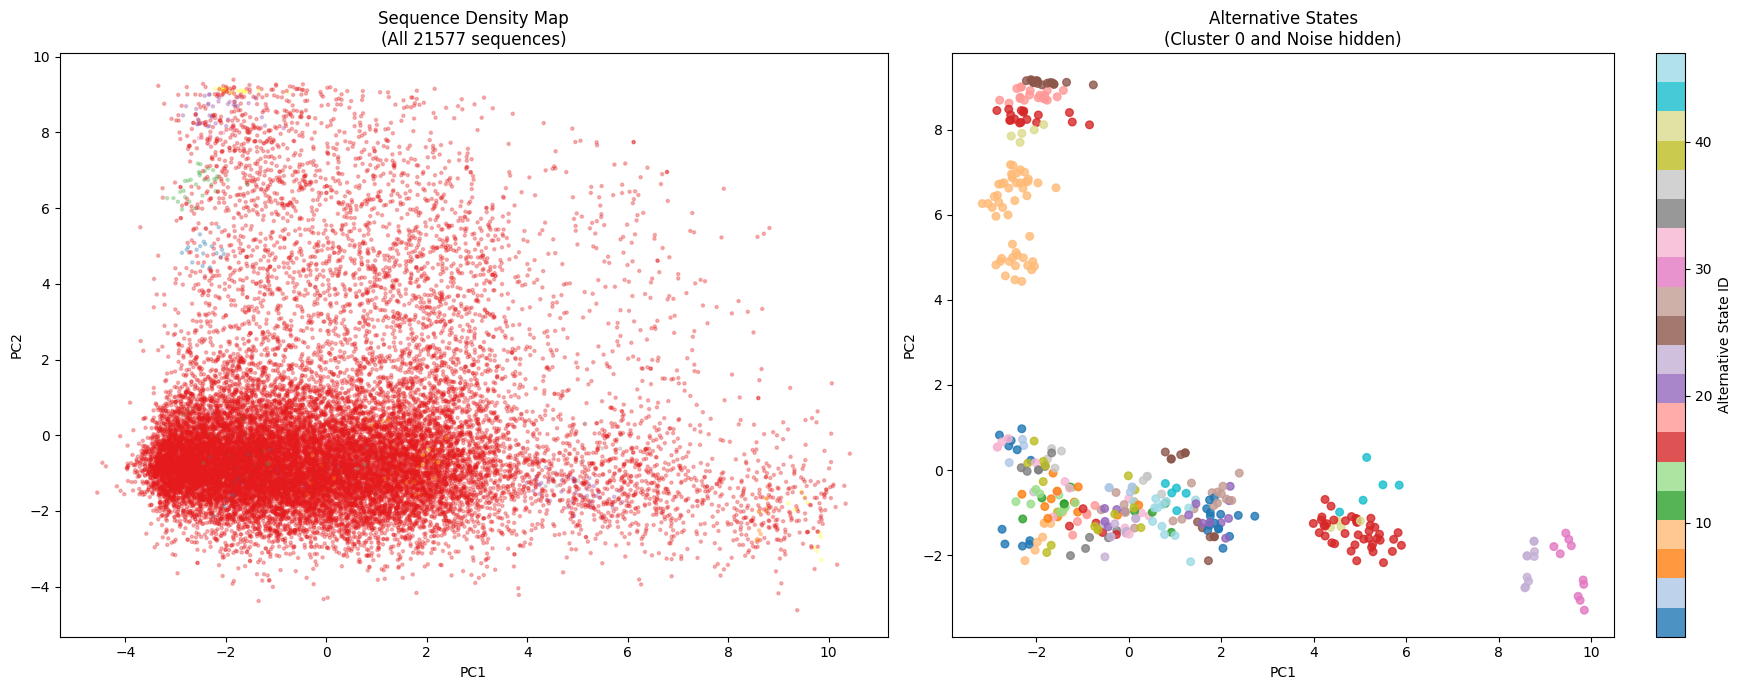

In [8]:
# --- IMPROVED VISUALIZATION FOR RESEARCH REPORT ---
import seaborn as sns

# 1. Statistics - How many sequences per state?
unique, counts = np.unique(cluster_labels, return_counts=True)
cluster_stats = dict(zip(unique, counts))
print("--- Cluster Distribution ---")
for cluster_id, count in cluster_stats.items():
    label = "Noise" if cluster_id == -1 else f"State {cluster_id}"
    print(f"{label}: {count} sequences ({count/len(cluster_labels)*100:.1f}%)")

# 2. Dual-View Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# View A: Density Map (All points with transparency)
# Using 's=5' and 'alpha=0.3' allows us to see through the 'red blob'
scatter1 = ax1.scatter(msa_pca[:, 0], msa_pca[:, 1], c=cluster_labels,
                       cmap='Set1', s=5, alpha=0.3)
ax1.set_title(f"Sequence Density Map\n(All {len(cluster_labels)} sequences)")
ax1.set_xlabel("PC1")
ax1.set_ylabel("PC2")

# View B: Focused View (Excluding the dominant Cluster 0)
# This allows you to see the "alternative states" clearly
mask = (cluster_labels != 0) & (cluster_labels != -1)
if np.any(mask):
    scatter2 = ax2.scatter(msa_pca[mask, 0], msa_pca[mask, 1], c=cluster_labels[mask],
                           cmap='tab20', s=30, alpha=0.8)
    ax2.set_title("Alternative States\n(Cluster 0 and Noise hidden)")
    plt.colorbar(scatter2, ax=ax2, label="Alternative State ID")
else:
    ax2.text(0.5, 0.5, "No significant alternative states found\nat current DBSCAN settings",
             ha='center', va='center')
    ax2.set_title("Alternative States View")

ax2.set_xlabel("PC1")
ax2.set_ylabel("PC2")

plt.tight_layout()
plt.show()

In [9]:
# --- MODULE 3: SUB-MSA GENERATION & STORAGE ---
import os

# 1. Create a directory to store the sub-MSAs
clusters_dir = "cluster_output_msas"
os.makedirs(clusters_dir, exist_ok=True)

if 'cluster_labels' in locals() and 'lines' in locals():
    print(f"Generating sub-MSAs for {n_clusters} clusters...")

    # 2. Group the original A3M text by clusters
    # Headers start with '>', sequences follow.
    msa_data = []
    current_header = ""
    for line in lines:
        if line.startswith(">"):
            current_header = line.strip()
        else:
            if current_header:
                msa_data.append((current_header, line.strip()))
                current_header = ""

    # 3. Create a file for each cluster
    for cluster_id in range(n_clusters):
        cluster_file = os.path.join(clusters_dir, f"cluster_{cluster_id}.a3m")

        # Get indices of sequences belonging to this cluster
        indices = [i for i, label in enumerate(cluster_labels) if label == cluster_id]

        with open(cluster_file, "w") as f:
            # AlphaFold ALWAYS needs the query sequence (index 0) at the top of every cluster
            f.write(f"{msa_data[0][0]}\n{msa_data[0][1]}\n")

            # Write the rest of the sequences in the cluster
            for idx in indices:
                if idx == 0: continue # Skip query if it's already in the cluster
                header, seq = msa_data[idx]
                f.write(f"{header}\n{seq}\n")

        print(f"✅ Saved Cluster {cluster_id} ({len(indices)} sequences) to {cluster_file}")

    print(f"\n--- ALL SUB-MSAs STORED IN '{clusters_dir}' FOLDER ---")
else:
    print("❌ Error: Please run Module 2 (Clustering) first to generate labels.")

Generating sub-MSAs for 48 clusters...
✅ Saved Cluster 0 (3553 sequences) to cluster_output_msas/cluster_0.a3m
✅ Saved Cluster 1 (5 sequences) to cluster_output_msas/cluster_1.a3m
✅ Saved Cluster 2 (6 sequences) to cluster_output_msas/cluster_2.a3m
✅ Saved Cluster 3 (15 sequences) to cluster_output_msas/cluster_3.a3m
✅ Saved Cluster 4 (5 sequences) to cluster_output_msas/cluster_4.a3m
✅ Saved Cluster 5 (3 sequences) to cluster_output_msas/cluster_5.a3m
✅ Saved Cluster 6 (10 sequences) to cluster_output_msas/cluster_6.a3m
✅ Saved Cluster 7 (3 sequences) to cluster_output_msas/cluster_7.a3m
✅ Saved Cluster 8 (18 sequences) to cluster_output_msas/cluster_8.a3m
✅ Saved Cluster 9 (8 sequences) to cluster_output_msas/cluster_9.a3m
✅ Saved Cluster 10 (31 sequences) to cluster_output_msas/cluster_10.a3m
✅ Saved Cluster 11 (4 sequences) to cluster_output_msas/cluster_11.a3m
✅ Saved Cluster 12 (5 sequences) to cluster_output_msas/cluster_12.a3m
✅ Saved Cluster 13 (5 sequences) to cluster_output_